![Screenshot 2026-08-17 192429.png](<attachment:Screenshot 2026-08-17 192429.png>)
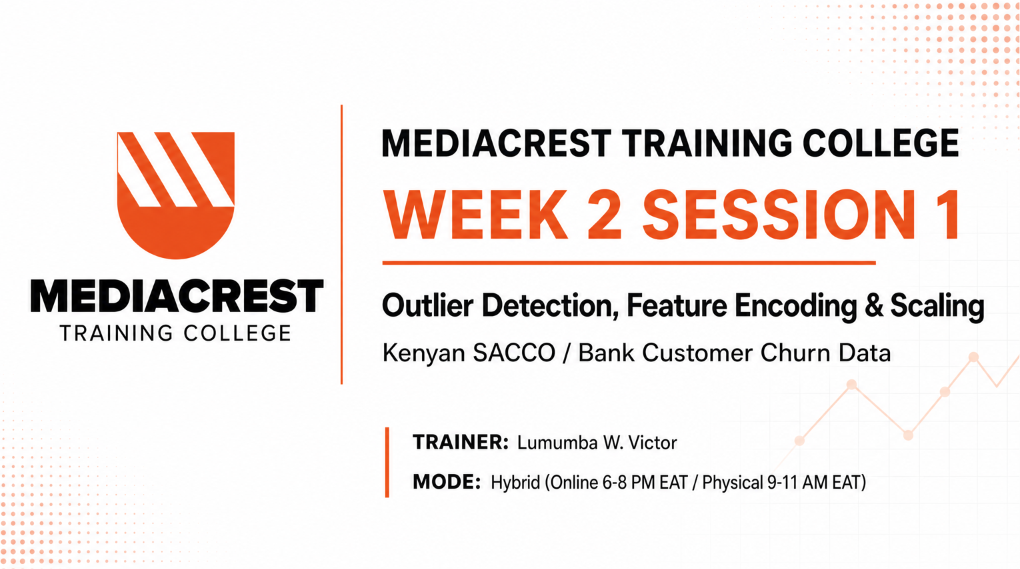

## **1. DATA IMPORTATION**

### **1.1. Import the Needed Libraries**

In [ ]:
!pip install pandas

In [2]:
import pandas as pd                  ## for pandas manipulation
import numpy as np                   ## for numeric manipulaltion
import matplotlib.pyplot as plt      ## for data visualization
import seaborn as sn                 ## for data visualization

### Filter Warnings
import warnings
warnings.filterwarnings("ignore")

### **1.2. Read the Data Into VS Code Jupyter Environment**

In [3]:
df = pd.read_csv("GSSsubset1.csv")
df.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,HIGH SCHOOL,26722.56,NEVER MARRIED,18,73.2,86.3,35.0
1,2,MALE,NaN,36544.91,MARRIED,35,69.9,95.3,47.0
2,3,FEMALE,HIGH SCHOOL,59587.14,DIVORCED,28,70.1,60.9,16.0
3,4,FEMALE,GRADUATE,NaN,MARRIED,43,61.9,76.0,44.0
4,5,MALE,HIGH SCHOOL,48899.47,MARRIED,48,65.8,58.9,44.0


### **1.3. General Data Inspection and EDA**

In [4]:
## Check the shape of the dataset
df.shape

(3000, 9)

In [5]:
### Check the data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3000 non-null   int64  
 1   sex      3000 non-null   object 
 2   degree   2942 non-null   object 
 3   income   2767 non-null   float64
 4   marital  2934 non-null   object 
 5   age      3000 non-null   int64  
 6   height   3000 non-null   float64
 7   weight   2879 non-null   float64
 8   hrswrk   2933 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 211.1+ KB


In [12]:
### Descriptive statistics of the dataset
df.drop(columns = ['id']).describe()

,income,age,height,weight,hrswrk
count,2767.000000,3000.000000,3000.000000,2879.000000,2933.000000
mean,63871.815790,42.078000,67.400500,76.389232,39.778043
std,51634.075898,13.314316,3.641297,14.584233,12.594723
min,3720.040000,18.000000,58.100000,45.000000,0.000000
25%,31989.025000,33.000000,64.600000,65.800000,34.000000
50%,49586.540000,42.000000,67.200000,75.700000,41.000000
75%,78986.595000,51.000000,70.100000,85.700000,48.000000
max,609741.180000,80.000000,78.600000,120.000000,79.000000


### **Missing Values Detection and Handling**

##### **Detect Missing Values**

In [13]:
df.isnull().sum()

id           0
sex          0
degree      58
income     233
marital     66
age          0
height       0
weight     121
hrswrk      67
dtype: int64

##### **Listwise Deletion of Misssing Values**

In [18]:
df = df.dropna()
df.head(10)

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,HIGH SCHOOL,26722.56,NEVER MARRIED,18,73.2,86.3,35.0
2,3,FEMALE,HIGH SCHOOL,59587.14,DIVORCED,28,70.1,60.9,16.0
4,5,MALE,HIGH SCHOOL,48899.47,MARRIED,48,65.8,58.9,44.0
5,6,FEMALE,HIGH SCHOOL,47790.38,MARRIED,43,60.7,68.4,46.0
6,7,FEMALE,BACHELOR,102903.23,MARRIED,42,66.5,66.7,51.0
7,8,MALE,HIGH SCHOOL,36707.09,NEVER MARRIED,52,65.9,76.8,48.0
8,9,FEMALE,BACHELOR,48404.51,MARRIED,35,66.8,94.6,28.0
10,11,FEMALE,GRADUATE,419380.86,SEPARATED,58,62.4,64.8,31.0
11,12,MALE,JUNIOR COLLEGE,14995.63,WIDOWED,40,66.8,68.7,45.0
12,13,FEMALE,LT HIGH SCHOOL,22832.15,WIDOWED,52,61.3,61.0,25.0


In [17]:
df.isnull().sum()

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2503 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       2503 non-null   int64  
 1   sex      2503 non-null   object 
 2   degree   2503 non-null   object 
 3   income   2503 non-null   float64
 4   marital  2503 non-null   object 
 5   age      2503 non-null   int64  
 6   height   2503 non-null   float64
 7   weight   2503 non-null   float64
 8   hrswrk   2503 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 195.5+ KB


#### **Checking and Handling Duplicates**

In [21]:
dup_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_rows}")

Number of duplicate rows: 0


##### **Drop Duplicates if Any Exists**

In [22]:
df = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows after removing duplicates: 2503


### **Detection of Outliers**

In [23]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
numeric_cols

Index(['id', 'income', 'age', 'height', 'weight', 'hrswrk'], dtype='object')

In [24]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col]> upper_bound)]
    print(f"Columns '{col}': {len(outliers)} Outliers")

Columns 'id': 0 Outliers
Columns 'income': 151 Outliers
Columns 'age': 8 Outliers
Columns 'height': 2 Outliers
Columns 'weight': 20 Outliers
Columns 'hrswrk': 133 Outliers


In [30]:
df.head(40)

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,HIGH SCHOOL,26722.56,NEVER MARRIED,18,73.2,86.3,35.0
2,3,FEMALE,HIGH SCHOOL,59587.14,DIVORCED,28,70.1,60.9,16.0
4,5,MALE,HIGH SCHOOL,48899.47,MARRIED,48,65.8,58.9,44.0
5,6,FEMALE,HIGH SCHOOL,47790.38,MARRIED,43,60.7,68.4,46.0
6,7,FEMALE,BACHELOR,102903.23,MARRIED,42,66.5,66.7,51.0
7,8,MALE,HIGH SCHOOL,36707.09,NEVER MARRIED,52,65.9,76.8,48.0
8,9,FEMALE,BACHELOR,48404.51,MARRIED,35,66.8,94.6,28.0
10,11,FEMALE,GRADUATE,419380.86,SEPARATED,58,62.4,64.8,31.0
11,12,MALE,JUNIOR COLLEGE,14995.63,WIDOWED,40,66.8,68.7,45.0
12,13,FEMALE,LT HIGH SCHOOL,22832.15,WIDOWED,52,61.3,61.0,25.0


In [26]:
numeric_cols = ["income", "age", "height", "weight", "hrswrk"]
numeric_cols

['income', 'age', 'height', 'weight', 'hrswrk']

In [28]:
outlier_id = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_id[col] = outliers['id'].tolist()
    print(f"Column '{col}': {len(outliers)} outliers")
    print(outliers['id'].tolist())
    print("-"*100)

Column 'income': 151 outliers
[11, 38, 76, 88, 102, 146, 200, 206, 223, 227, 244, 289, 326, 352, 359, 375, 397, 404, 437, 455, 460, 505, 523, 536, 544, 549, 568, 596, 603, 668, 727, 731, 761, 786, 797, 834, 847, 913, 923, 931, 946, 975, 976, 984, 1003, 1061, 1082, 1087, 1093, 1127, 1128, 1134, 1149, 1163, 1189, 1242, 1250, 1344, 1407, 1418, 1461, 1506, 1598, 1609, 1627, 1638, 1676, 1681, 1685, 1694, 1696, 1711, 1731, 1760, 1762, 1770, 1806, 1814, 1867, 1870, 1916, 1943, 1953, 1961, 1965, 2018, 2019, 2030, 2042, 2075, 2088, 2107, 2120, 2148, 2149, 2170, 2181, 2228, 2246, 2265, 2268, 2287, 2292, 2295, 2325, 2336, 2374, 2397, 2414, 2462, 2473, 2475, 2480, 2486, 2527, 2531, 2539, 2550, 2590, 2607, 2617, 2633, 2634, 2644, 2645, 2696, 2701, 2708, 2716, 2728, 2732, 2769, 2785, 2789, 2801, 2809, 2820, 2828, 2830, 2844, 2858, 2864, 2880, 2896, 2897, 2933, 2948, 2954, 2979, 2993, 2997]
----------------------------------------------------------------------------------------------------
Column 'ag

#### **Capping the Outliers**

In [31]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    ## Cap the Outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col]> upper_bound, upper_bound, df[col])

#### **Confirm the Presence or Absence of Outliers**

In [32]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col]> upper_bound)]
    print(f"Columns '{col}': {len(outliers)} Outliers")

Columns 'id': 0 Outliers
Columns 'income': 0 Outliers
Columns 'age': 0 Outliers
Columns 'height': 0 Outliers
Columns 'weight': 0 Outliers
Columns 'hrswrk': 0 Outliers


In [34]:
df.head(10)

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1.0,MALE,HIGH SCHOOL,26722.5600,NEVER MARRIED,18.0,73.2,86.3,35.0
2,3.0,FEMALE,HIGH SCHOOL,59587.1400,DIVORCED,28.0,70.1,60.9,16.0
4,5.0,MALE,HIGH SCHOOL,48899.4700,MARRIED,48.0,65.8,58.9,44.0
5,6.0,FEMALE,HIGH SCHOOL,47790.3800,MARRIED,43.0,60.7,68.4,46.0
6,7.0,FEMALE,BACHELOR,102903.2300,MARRIED,42.0,66.5,66.7,51.0
7,8.0,MALE,HIGH SCHOOL,36707.0900,NEVER MARRIED,52.0,65.9,76.8,48.0
8,9.0,FEMALE,BACHELOR,48404.5100,MARRIED,35.0,66.8,94.6,28.0
10,11.0,FEMALE,GRADUATE,149300.6475,SEPARATED,58.0,62.4,64.8,31.0
11,12.0,MALE,JUNIOR COLLEGE,14995.6300,WIDOWED,40.0,66.8,68.7,45.0
12,13.0,FEMALE,LT HIGH SCHOOL,22832.1500,WIDOWED,52.0,61.3,61.0,25.0


#### **Save the Clean GSS Subset Dataset**

In [35]:
df.to_csv("clean_gssdata.csv")